In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 47.6 MB/s eta 0:00:00


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aklimarimi/8-facial-expressions-for-yolo")

print("Path to dataset files:", path)

100%|██████████| 3.77G/3.77G [02:05<00:00, 32.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aklimarimi/8-facial-expressions-for-yolo/versions/4


In [3]:
import os
import torch
import torchvision
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as tt
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
%matplotlib inline

DATA_DIR = '/root/.cache/kagglehub/datasets/aklimarimi/8-facial-expressions-for-yolo/versions/4/9 Facial Expressions you need'
train = os.listdir(os.path.join(DATA_DIR,'train'))
test = os.listdir(os.path.join(DATA_DIR,'test'))
val=os.listdir(os.path.join(DATA_DIR,'valid'))
print(f'Train - {train}')
print(f'Test - {test}')
print(f'Val - {val}')

Train - ['labels', 'images']
Test - ['labels', 'images']
Val - ['labels', 'images']


In [4]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 48
EMOTIONS = ['Happy', 'Sad', 'Angry', 'Surprised', 'Neutral', 'Disgusted', 'Fear', 'Sleepy', 'Contempt']  # update based on your labels
emotion_to_idx = {e: i for i, e in enumerate(EMOTIONS)}
idx_to_emotion = {i: e for i, e in enumerate(EMOTIONS)} # Add mapping from index to emotion

def load_data(folder_path):
    image_dir = os.path.join(folder_path, 'images')
    label_dir = os.path.join(folder_path, 'labels')

    images = []
    labels = []

    # Get list of label files
    label_files = sorted([f for f in os.listdir(label_dir) if f.endswith('.txt')])

    for label_fname in label_files:
        image_fname = label_fname.replace('.txt', '.jpg')
        image_path = os.path.join(image_dir, image_fname)
        label_path = os.path.join(label_dir, label_fname)

        # Check if the corresponding image file exists
        if not os.path.exists(image_path):
            print(f"Warning: Image file not found for label file {label_path}. Skipping.")
            continue

        # Load image in grayscale
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Warning: Could not read image file {image_path}. Skipping.")
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to 48×48
        images.append(img)

        # Load and parse label from YOLO format
        with open(label_path, 'r') as f:
            label_content = f.read().strip()
            # Assuming the first number in the line is the class ID
            try:
                class_id = int(label_content.split()[0])
                labels.append(class_id)
            except (ValueError, IndexError):
                print(f"Warning: Could not parse label from file {label_path}. Content: '{label_content}'. Skipping.")
                images.pop() # Remove the image if label parsing fails
                continue


    images = np.array(images)
    labels = np.array(labels)
    return images, labels


# Load full data from train folder
images, labels = load_data(os.path.join(DATA_DIR, 'test'))

# Normalize pixel values to be between 0 and 1
images = images / 255.0

# Reduce dataset size
n_train = 5000
n_test = 3000

train_images = images[:n_train]
train_labels = labels[:n_train]
test_images = images[-n_test:]
test_labels = labels[-n_test:]

# Add grayscale channel dimension: (N, 48, 48, 1)
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

# One-hot encode the labels
train_labels_categorical = to_categorical(train_labels, num_classes=len(EMOTIONS))
test_labels_categorical = to_categorical(test_labels, num_classes=len(EMOTIONS))

# Final checks
print(f"Train images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Train labels shape: {train_labels_categorical.shape}")
print(f"Test labels shape: {test_labels_categorical.shape}")

Train images shape: (1700, 48, 48, 1)
Test images shape: (1700, 48, 48, 1)
Train labels shape: (1700, 9)
Test labels shape: (1700, 9)


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(



=== Running for 6 Qubits ===

Quantum Circuit for 6 Qubits:


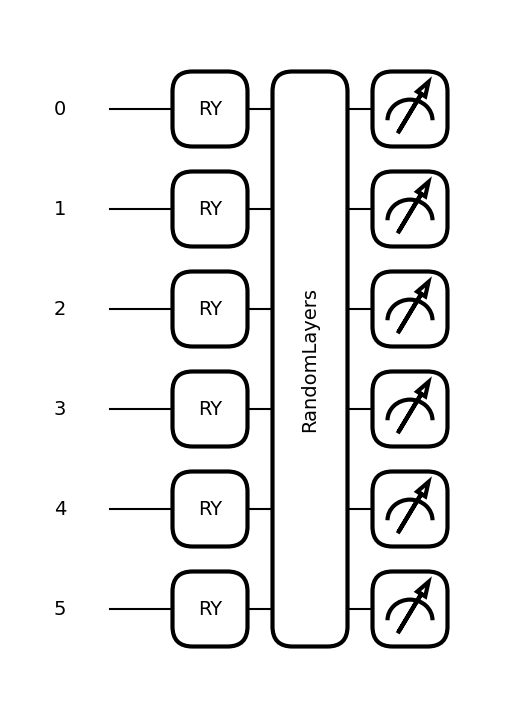

Quantum preprocessing (train)...
Quantum preprocessing (test)...


In [5]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Fix random seeds
np.random.seed(1)
tf.random.set_seed(1)

# Number of classes (for this dataset)
num_classes = len(EMOTIONS)

# Define qubit patch sizes
qubit_patch_shapes = {
    4: (2, 2),
    6: (3, 2),
    8: (4, 2),
    10: (5, 2),
    12: (4, 3),
}

# ------------------ Quantum Circuit Creation -------------------
def create_circuit(n_qubits, n_layers=1):
    dev = qml.device("default.qubit", wires=n_qubits)
    rand_params = np.random.uniform(high=2*np.pi, size=(n_layers, n_qubits))

    @qml.qnode(dev)
    def circuit(phi):
        # Encode classical data into qubits
        for j in range(n_qubits):
            qml.RY(np.pi * phi[j], wires=j)
        RandomLayers(rand_params, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]

    return circuit

# ------------------ Quantum Convolution -------------------
def quanv(image, circuit, patch_h, patch_w):
    out_h = (image.shape[0] - patch_h) // 2 + 1
    out_w = (image.shape[1] - patch_w) // 2 + 1
    n_qubits = patch_h * patch_w
    out = np.zeros((out_h, out_w, n_qubits))
    for j in range(0, image.shape[0] - patch_h + 1, 2):
        for k in range(0, image.shape[1] - patch_w + 1, 2):
            patch = image[j:j+patch_h, k:k+patch_w, 0].flatten()
            q_results = circuit(patch)
            out[j//2, k//2, :] = q_results
    return out

def build_model(input_shape, num_classes):
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=input_shape),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

results = {}
n_qubits=6

print(f"\n=== Running for {n_qubits} Qubits ===")
patch_h, patch_w = qubit_patch_shapes[n_qubits]
circuit = create_circuit(n_qubits)

# Show quantum circuit diagram
print(f"\nQuantum Circuit for {n_qubits} Qubits:")
fig, ax = qml.draw_mpl(circuit)(np.random.rand(n_qubits))
plt.show()

# Quantum preprocessing
print("Quantum preprocessing (train)...")
q_train_images = np.array([quanv(img, circuit, patch_h, patch_w) for img in train_images])
print("Quantum preprocessing (test)...")
q_test_images = np.array([quanv(img, circuit, patch_h, patch_w) for img in test_images])

 Running Quantum CNN for Seed = 0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
213/213 - 3s - 16ms/step - accuracy: 0.2212 - loss: 2.2268 - val_accuracy: 0.2906 - val_loss: 1.8605
Epoch 2/250
213/213 - 2s - 8ms/step - accuracy: 0.2641 - loss: 1.9766 - val_accuracy: 0.3324 - val_loss: 1.8494
Epoch 3/250
213/213 - 3s - 13ms/step - accuracy: 0.3076 - loss: 1.8726 - val_accuracy: 0.3918 - val_loss: 1.7147
Epoch 4/250
213/213 - 4s - 19ms/step - accuracy: 0.3153 - loss: 1.7951 - val_accuracy: 0.4188 - val_loss: 1.6500
Epoch 5/250
213/213 - 2s - 9ms/step - accuracy: 0.3635 - loss: 1.6961 - val_accuracy: 0.4435 - val_loss: 1.5268
Epoch 6/250
213/213 - 2s - 8ms/step - accuracy: 0.3959 - loss: 1.6311 - val_accuracy: 0.4759 - val_loss: 1.5015
Epoch 7/250
213/213 - 2s - 8ms/step - accuracy: 0.4129 - loss: 1.5609 - val_accuracy: 0.4753 - val_loss: 1.4306
Epoch 8/250
213/213 - 2s - 11ms/step - accuracy: 0.4388 - loss: 1.4961 - val_accuracy: 0.5441 - val_loss: 1.3134
Epoch 9/250
213/213 - 2s - 10ms/step - accuracy: 0.4429 - loss: 1.4419 - val_accuracy: 0.5582 - val_

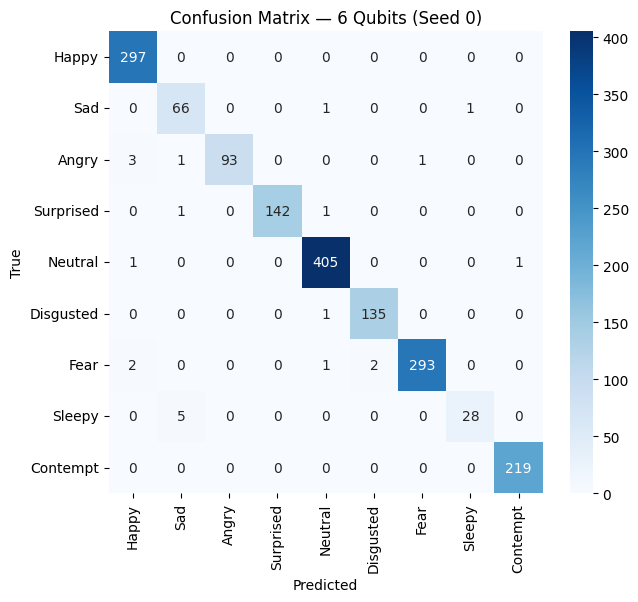

 Running Quantum CNN for Seed = 1
Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


213/213 - 3s - 13ms/step - accuracy: 0.2312 - loss: 2.2077 - val_accuracy: 0.3029 - val_loss: 1.9152
Epoch 2/250
213/213 - 3s - 13ms/step - accuracy: 0.2853 - loss: 1.9550 - val_accuracy: 0.3565 - val_loss: 1.7524
Epoch 3/250
213/213 - 4s - 20ms/step - accuracy: 0.3235 - loss: 1.8417 - val_accuracy: 0.3929 - val_loss: 1.6640
Epoch 4/250
213/213 - 2s - 9ms/step - accuracy: 0.3294 - loss: 1.7796 - val_accuracy: 0.4012 - val_loss: 1.6076
Epoch 5/250
213/213 - 2s - 8ms/step - accuracy: 0.3571 - loss: 1.6975 - val_accuracy: 0.4559 - val_loss: 1.5334
Epoch 6/250
213/213 - 2s - 8ms/step - accuracy: 0.3835 - loss: 1.6488 - val_accuracy: 0.4718 - val_loss: 1.4827
Epoch 7/250
213/213 - 3s - 14ms/step - accuracy: 0.4141 - loss: 1.5891 - val_accuracy: 0.5024 - val_loss: 1.4023
Epoch 8/250
213/213 - 2s - 8ms/step - accuracy: 0.4329 - loss: 1.4929 - val_accuracy: 0.5194 - val_loss: 1.3551
Epoch 9/250
213/213 - 2s - 8ms/step - accuracy: 0.4453 - loss: 1.4672 - val_accuracy: 0.5412 - val_loss: 1.3425


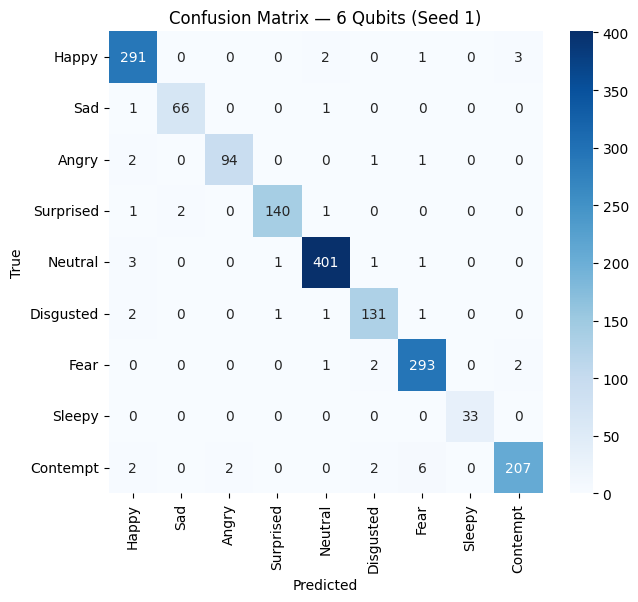

 Running Quantum CNN for Seed = 2
Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


213/213 - 4s - 18ms/step - accuracy: 0.2006 - loss: 2.2112 - val_accuracy: 0.2900 - val_loss: 1.9345
Epoch 2/250
213/213 - 2s - 8ms/step - accuracy: 0.2571 - loss: 1.9769 - val_accuracy: 0.3729 - val_loss: 1.7573
Epoch 3/250
213/213 - 3s - 12ms/step - accuracy: 0.3000 - loss: 1.8661 - val_accuracy: 0.3547 - val_loss: 1.7166
Epoch 4/250
213/213 - 2s - 9ms/step - accuracy: 0.3241 - loss: 1.7888 - val_accuracy: 0.4182 - val_loss: 1.6543
Epoch 5/250
213/213 - 2s - 9ms/step - accuracy: 0.3559 - loss: 1.7159 - val_accuracy: 0.4471 - val_loss: 1.5604
Epoch 6/250
213/213 - 2s - 11ms/step - accuracy: 0.3694 - loss: 1.6679 - val_accuracy: 0.4741 - val_loss: 1.4650
Epoch 7/250
213/213 - 2s - 11ms/step - accuracy: 0.4000 - loss: 1.5966 - val_accuracy: 0.4859 - val_loss: 1.4005
Epoch 8/250
213/213 - 2s - 9ms/step - accuracy: 0.3982 - loss: 1.5391 - val_accuracy: 0.5265 - val_loss: 1.3626
Epoch 9/250
213/213 - 2s - 8ms/step - accuracy: 0.4335 - loss: 1.4708 - val_accuracy: 0.5329 - val_loss: 1.3166


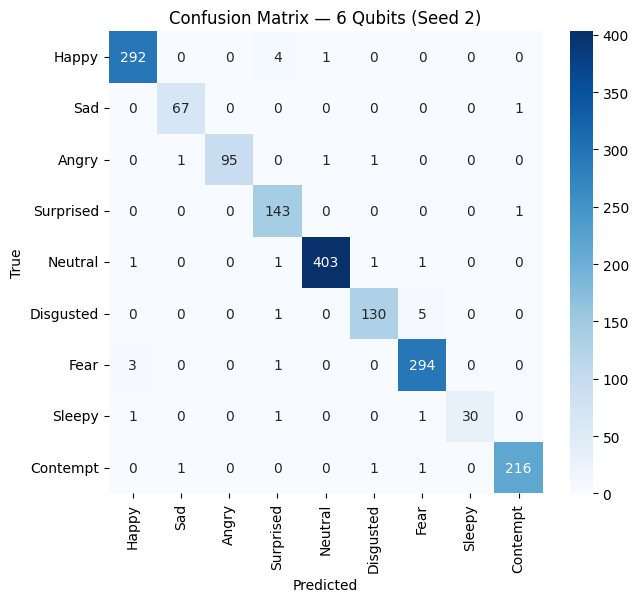

 Running Quantum CNN for Seed = 3
Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


213/213 - 3s - 13ms/step - accuracy: 0.2224 - loss: 2.2270 - val_accuracy: 0.2900 - val_loss: 1.8746
Epoch 2/250
213/213 - 3s - 14ms/step - accuracy: 0.2706 - loss: 1.9746 - val_accuracy: 0.3712 - val_loss: 1.7532
Epoch 3/250
213/213 - 2s - 8ms/step - accuracy: 0.3029 - loss: 1.8919 - val_accuracy: 0.3912 - val_loss: 1.6636
Epoch 4/250
213/213 - 2s - 8ms/step - accuracy: 0.3347 - loss: 1.7613 - val_accuracy: 0.4412 - val_loss: 1.5707
Epoch 5/250
213/213 - 2s - 8ms/step - accuracy: 0.3453 - loss: 1.7267 - val_accuracy: 0.4694 - val_loss: 1.4719
Epoch 6/250
213/213 - 2s - 8ms/step - accuracy: 0.3988 - loss: 1.6191 - val_accuracy: 0.4935 - val_loss: 1.4126
Epoch 7/250
213/213 - 2s - 8ms/step - accuracy: 0.4076 - loss: 1.5653 - val_accuracy: 0.5312 - val_loss: 1.3441
Epoch 8/250
213/213 - 2s - 10ms/step - accuracy: 0.4329 - loss: 1.4971 - val_accuracy: 0.5429 - val_loss: 1.2589
Epoch 9/250
213/213 - 2s - 11ms/step - accuracy: 0.4600 - loss: 1.4100 - val_accuracy: 0.5547 - val_loss: 1.2345


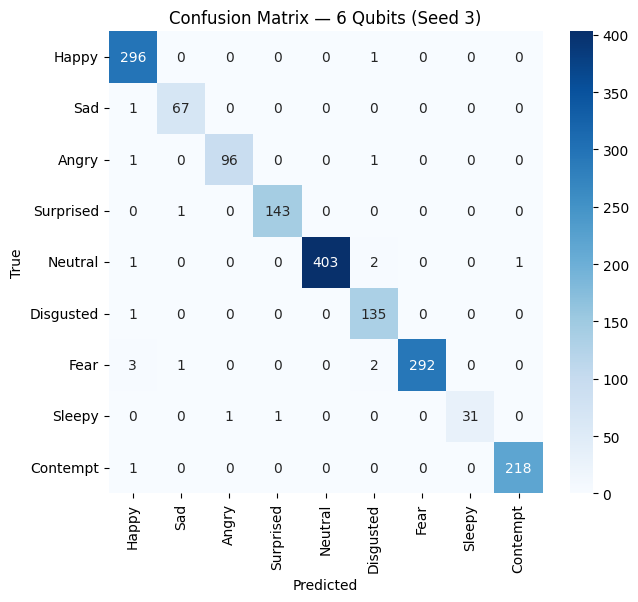

 Running Quantum CNN for Seed = 4
Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


213/213 - 3s - 13ms/step - accuracy: 0.2341 - loss: 2.2083 - val_accuracy: 0.2906 - val_loss: 1.8913
Epoch 2/250
213/213 - 2s - 8ms/step - accuracy: 0.2759 - loss: 1.9520 - val_accuracy: 0.3471 - val_loss: 1.7687
Epoch 3/250
213/213 - 2s - 8ms/step - accuracy: 0.3059 - loss: 1.8693 - val_accuracy: 0.3900 - val_loss: 1.7012
Epoch 4/250
213/213 - 2s - 8ms/step - accuracy: 0.3288 - loss: 1.7741 - val_accuracy: 0.4118 - val_loss: 1.6251
Epoch 5/250
213/213 - 2s - 11ms/step - accuracy: 0.3559 - loss: 1.7129 - val_accuracy: 0.4765 - val_loss: 1.5265
Epoch 6/250
213/213 - 2s - 10ms/step - accuracy: 0.3776 - loss: 1.6227 - val_accuracy: 0.4871 - val_loss: 1.4690
Epoch 7/250
213/213 - 2s - 8ms/step - accuracy: 0.4106 - loss: 1.5718 - val_accuracy: 0.5265 - val_loss: 1.3875
Epoch 8/250
213/213 - 2s - 9ms/step - accuracy: 0.4229 - loss: 1.4970 - val_accuracy: 0.5488 - val_loss: 1.3150
Epoch 9/250
213/213 - 2s - 9ms/step - accuracy: 0.4435 - loss: 1.4541 - val_accuracy: 0.5506 - val_loss: 1.3008
E

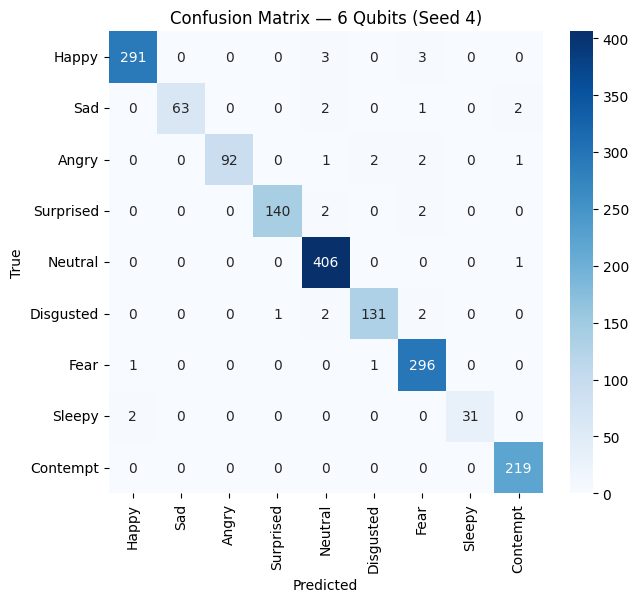


Final Summary Across Seeds (6 Qubits)
   Seed  Accuracy       AUC        F1
0     0  0.987059  0.999914  0.973941
1     1  0.974118  0.999689  0.974540
2     2  0.982353  0.999749  0.977256
3     3  0.988824  0.999933  0.984956
4     4  0.981765  0.999810  0.977146

Mean ± Std and 95% CI:
  Accuracy : 0.9828 ± 0.0057  (95% CI: [0.9757, 0.9899])
  Macro AUC: 0.9998 ± 0.0001  (95% CI: [0.9997, 0.9999])
  Macro F1 : 0.9776 ± 0.0044  (95% CI: [0.9721, 0.9830])


In [6]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st


n_qubits = 6
num_classes = len(EMOTIONS)
seeds = [0, 1, 2, 3, 4]


results = []

for seed in seeds:
    print(f" Running Quantum CNN for Seed = {seed}")

    # Fix random seed for reproducibility
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Build and train model
    model = build_model(q_train_images.shape[1:], num_classes)
    history = model.fit(q_train_images, train_labels, validation_data=(q_test_images, test_labels),
                        epochs=250, batch_size=8, verbose=2)

    # Predictions
    y_pred_prob = model.predict(q_test_images)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Accuracy
    acc = np.mean(y_pred == test_labels)

    # One-hot encode labels for AUC
    y_true_onehot = keras.utils.to_categorical(test_labels, num_classes=num_classes)
    try:
        macro_auc = roc_auc_score(y_true_onehot, y_pred_prob, multi_class='ovr', average='macro')
    except ValueError:
        macro_auc = np.nan

    # Macro F1
    macro_f1 = f1_score(test_labels, y_pred, average='macro')

    print(f"\nSeed {seed} Results:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro AUC: {macro_auc:.4f}")
    print(f"  Macro F1 : {macro_f1:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(test_labels, y_pred, target_names=EMOTIONS, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.title(f'Confusion Matrix — 6 Qubits (Seed {seed})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Store results
    results.append({
        'Seed': seed,
        'Accuracy': acc,
        'AUC': macro_auc,
        'F1': macro_f1
    })


results_df = pd.DataFrame(results)
mean_acc, std_acc = results_df['Accuracy'].mean(), results_df['Accuracy'].std(ddof=1)
mean_auc, std_auc = results_df['AUC'].mean(), results_df['AUC'].std(ddof=1)
mean_f1, std_f1 = results_df['F1'].mean(), results_df['F1'].std(ddof=1)

# 95% Confidence Intervals
ci_acc = st.t.interval(0.95, len(results_df)-1, loc=mean_acc, scale=st.sem(results_df['Accuracy']))
ci_auc = st.t.interval(0.95, len(results_df)-1, loc=mean_auc, scale=st.sem(results_df['AUC']))
ci_f1 = st.t.interval(0.95, len(results_df)-1, loc=mean_f1, scale=st.sem(results_df['F1']))

print("\nFinal Summary Across Seeds (6 Qubits)")
print(results_df)
print(f"\nMean ± Std and 95% CI:")
print(f"  Accuracy : {mean_acc:.4f} ± {std_acc:.4f}  (95% CI: [{ci_acc[0]:.4f}, {ci_acc[1]:.4f}])")
print(f"  Macro AUC: {mean_auc:.4f} ± {std_auc:.4f}  (95% CI: [{ci_auc[0]:.4f}, {ci_auc[1]:.4f}])")
print(f"  Macro F1 : {mean_f1:.4f} ± {std_f1:.4f}  (95% CI: [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}])")
